# 7 -- Modelo LSTM del pipeline hibrido — Dataset FDIC RIS

Con los embeddings relacionales e_rel del bloque de desarrollo ya extraidos y validados, el siguiente paso es entrenar el componente LSTM del modelo estrella siguiendo el mismo protocolo que en el Baseline, con una unica diferencia sustancial en la entrada: en lugar de las secuencias de e_tab de dimension 192, se construyen secuencias de e_rel de dimension 32.
El procedimiento es identico en estructura. Se parte de los 125.575 pares (CERT, period) del bloque de desarrollo, se asignan indices de periodo, se fija la misma frontera train/val de N_VAL_PERIODS=8 (2020Q1 a 2021Q4) que demostro empiricamente dejar positivos suficientes en validacion para un early stopping estable, y se construyen ventanas deslizantes de longitud T=4 con stride=1 y consecutividad estricta por CERT. El dataset, el DataLoader y el bucle de entrenamiento con early stopping sobre AUC-PR son los mismos que en el Baseline.
Los cambios respecto al Baseline son tres y estan acotados. Primero, la fuente de embeddings pasa de emb_dev (e_tab, 192 dims) a erel_dev (e_rel, 32 dims), con la misma estructura de columnas META + dims flotantes. Segundo, el parametro d_in del LSTMBaseline pasa de 192 a 32. Tercero, pos_weight se recalcula sobre las secuencias construidas desde e_rel, aunque al compartir exactamente la misma poblacion de pares (CERT, period) y la misma frontera train/val, el valor resultante deberia ser identico o negligiblemente distinto al del Baseline.
El resto del pipeline, arquitectura LSTM con hidden_dim=32, optimizador AdamW, scheduler ReduceLROnPlateau, clip de gradiente, y criterio BCEWithLogitsLoss con pw_factor, se mantiene sin cambios para que la comparacion entre Baseline y modelo estrella sea atribuible exclusivamente a la representacion de entrada y no a diferencias de entrenamiento.

In [31]:
# ============================================================
# CELDA 1 — Configuración global
# ============================================================
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch_geometric.utils import to_dense_adj
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score
)

# Paths — ajustar si la estructura de directorios difiere
#ROOT   = Path('D:/financial_risk_data')
#GRAPHS = ROOT / 'graphs'
#MODELS = ROOT / 'models_checkpoints'
MODELS = 'models_checkpoints'


# Añadir models/ al path para importar tgcn.py
#sys.path.insert(0, str(ROOT / 'src'))

# Reproducibilidad
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device: GPU si está disponible (Colab), CPU en local
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cpu


In [11]:
# ============================================================================
# BLOQUE 1 — CARGA Y VERIFICACIÓN DE EMBEDDINGS DE DESARROLLO RELACIONALES (e_rel)
# ============================================================================
#
# Modelo: LSTM (solo datos numéricos/relaciones tabulares vía T-GCN)
#
# Objetivo de este bloque: cargar erel_desarrollo.parquet, verificar
# su consistencia con el panel etiquetado original, y dejar un DataFrame
# único (emb_dev_rel_labeled) listo para la construcción de secuencias del
# Bloque 2.
#
# NO se toca en ningún momento el bloque de evaluación (2022Q1-2025Q4):
# permanece reservado hasta la evaluación final del modelo ya entrenado.
# ============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

# ----------- 1.0 REPRODUCIBILIDAD -----------
SEED = 42
np.random.seed(SEED)

# ----------- 1.1 RUTAS -----------
DATA_ROOT = Path("D:/financial_risk_data")
EMBEDDINGS_ROOT = DATA_ROOT / "embeddings"

EMB_DEV_PATH = EMBEDDINGS_ROOT / "emb_rel_dev/erel_desarrollo.parquet"
PANEL_LABEL_PATH = DATA_ROOT / "processed" / "panel_tabular_labeled.parquet"


# Carga de ambos embeddings y del panel de etiquetas para google colab
emb_dev_rel    = pd.read_parquet("D:/financial_risk_data/embeddings/emb_rel_dev/erel_desarrollo.parquet")
panel_label = pd.read_parquet("D:/financial_risk_data/processed/panel_tabular_labeled.parquet")

VERBOSE = True

# ----------- 1.2 CARGA -----------
emb_dev_rel = pd.read_parquet(EMB_DEV_PATH)
panel_label = pd.read_parquet(PANEL_LABEL_PATH)

if VERBOSE:
    print(f"emb_dev_rel shape     : {emb_dev_rel.shape}")
    print(f"panel_label shape : {panel_label.shape}")

# ----------- 1.3 NORMALIZACIÓN DE TIPOS -----------
for df in [emb_dev_rel, panel_label]:
    df["CERT"] = df["CERT"].astype(str)
    df["period"] = df["period"].astype(str)

# ----------- 1.4 IDENTIFICAR COLUMNAS DE EMBEDDING -----------
META_DEV = ["CERT", "period", "y"]
cols_emb = [c for c in emb_dev_rel.columns if c not in META_DEV]

assert len(cols_emb) == 32, (
    f"Se esperaban 32 dimensiones de embedding (espacio latente de "
    f"T-GCN), se encontraron {len(cols_emb)}."
)

# ----------- 1.5 UNIR ETIQUETA failed DESDE panel_tabular_labeled -----------
# Se usa la MISMA fuente de etiqueta para garantizar comparabilidad histórica de los números.
# how='left' + fillna(0): un CERT/period sin entrada en panel_label se
# asume no-quiebra (consistente con el procesamiento ya usado en el
# documento de extracción de TabPFN: panel['failed'].fillna(0).astype(int)).

emb_dev_rel_labeled = emb_dev_rel.merge(
    panel_label[["CERT", "period", "failed"]],
    on=["CERT", "period"],
    how="left",
)
n_sin_etiqueta = emb_dev_rel_labeled["failed"].isna().sum()
emb_dev_rel_labeled["failed"] = emb_dev_rel_labeled["failed"].fillna(0).astype(int)

# ----------- 1.6 VERIFICACIÓN DE INVARIANTES -----------
n_obs = len(emb_dev_rel_labeled)
n_pos = int(emb_dev_rel_labeled["failed"].sum())
n_nan_emb = emb_dev_rel_labeled[cols_emb].isna().sum().sum()
n_periodos = emb_dev_rel_labeled["period"].nunique()
periodos_sorted = sorted(emb_dev_rel_labeled["period"].unique())

assert n_nan_emb == 0, f"NaN en columnas de embedding: {n_nan_emb}"
assert n_periodos == 23, (
    f"Periodos esperados: 23 (2016Q2→2021Q4, 2016Q1 omitido por falta de "
    f"contexto TabPFN), obtenidos: {n_periodos}"
)
assert periodos_sorted[0] == "2016Q2", f"Primer periodo inesperado: {periodos_sorted[0]}"
assert periodos_sorted[-1] == "2021Q4", f"Último periodo inesperado: {periodos_sorted[-1]}"

# Verificación cruzada: el nº de positivos debe ser compatible con los 70
# positivos documentados para el bloque desarrollo completo (2016Q1-2021Q4,
# 24 trimestres). Al faltar 2016Q1 en el embedding, se espera un nº de
# positivos ligeramente MENOR o IGUAL a 70 (los de 2016Q1 no tienen
# embedding y por tanto no pueden entrar en ninguna secuencia).
if VERBOSE:
    print("\n" + "=" * 60)
    print("BLOQUE 1 — VERIFICACIÓN DE EMBEDDINGS DE DESARROLLO (e_rel)")
    print("=" * 60)
    print(f"Observaciones totales        : {n_obs:,}")
    print(f"Positivos (failed=1)         : {n_pos}")
    print(f"Tasa de positivos            : {n_pos/n_obs:.6f}")
    print(f"Filas sin match en panel_label (asumidas failed=0) : {n_sin_etiqueta}")
    print(f"Dimensión de embedding        : {len(cols_emb)}")
    print(f"NaN en embeddings             : {n_nan_emb}")
    print(f"Periodos                      : {n_periodos}  ({periodos_sorted[0]} → {periodos_sorted[-1]})")
    print(f"Entidades (CERT) únicas       : {emb_dev_rel_labeled['CERT'].nunique():,}")
    print("=" * 60)


emb_dev_rel shape     : (125575, 35)
panel_label shape : (206129, 3)

BLOQUE 1 — VERIFICACIÓN DE EMBEDDINGS DE DESARROLLO (e_rel)
Observaciones totales        : 125,575
Positivos (failed=1)         : 63
Tasa de positivos            : 0.000502
Filas sin match en panel_label (asumidas failed=0) : 0
Dimensión de embedding        : 32
NaN en embeddings             : 0
Periodos                      : 23  (2016Q2 → 2021Q4)
Entidades (CERT) únicas       : 6,176


In [12]:
assert (emb_dev_rel_labeled["y"].astype(int) == emb_dev_rel_labeled["failed"]).all(), \
    "Discrepancia entre columna 'y' del T-GCN y 'failed' de panel_label"
print("Verificacion y == failed: OK")

Verificacion y == failed: OK


Pasamos al Bloque 2. El codigo es una traslacion directa del Baseline cambiando tres cosas: la variable de entrada es emb_dev_labeled construida desde e_rel, cols_emb tiene 32 dimensiones en vez de 192, y d_in=32 en la instanciacion del modelo. Las funciones del modulo temporal_sequences y el resto del pipeline se invocan identicos.
Lo unico que hay que recalcular desde cero es pos_weight_raw, porque aunque el numero de positivos en secuencias de train deberia ser muy similar al Baseline, el numero total de secuencias validas puede diferir ligeramente si algun CERT tiene continuidad en e_tab pero no en e_rel o viceversa, lo que cambiaria el denominador del ratio.
La frontera N_VAL_PERIODS=8 se mantiene por la misma justificacion empirica que en el Baseline: es la frontera minima que garantiza positivos suficientes en validacion para que el early stopping sobre AUC-PR sea estable.
Pasa el output del bloque de verificacion de secuencias y del diagnostico de batches cuando los tengas, para confirmar que los numeros de positivos en train y val cuadran con lo esperado antes de instanciar el modelo.

In [48]:
# ============================================================================
# BLOQUE 2   — CONSTRUCCIÓN DE SECUENCIAS TEMPORALES (target supervisado)
# ============================================================================
#
# Ventana deslizante T=4, stride=1, consecutividad estricta

# Diferencia respecto al diseño anterior: `failed` en period_end es ahora
# el TARGET de la función de pérdida (BCEWithLogitsLoss), no un metadato
# informativo. La frontera train/val se fija en N_VAL_PERIODS=8
# (2020Q1→2021Q4), justificada empíricamente en el Bloque 2a: deja 7
# positivos en val frente a 2 con la frontera genérica anterior (N=4),
# dando una señal de validación más estable para early stopping vía AUC-PR.
# ============================================================================

import importlib
import sys
import os


# Retroceder un nivel desde 'notebooks' para llegar a la raíz del proyecto
proyecto_raiz = os.path.abspath(os.path.join(os.getcwd(), ".."))

if proyecto_raiz not in sys.path:
    sys.path.insert(0, proyecto_raiz)


if "src.utils.temporal_sequences" in sys.modules:
    importlib.reload(sys.modules["src.utils.temporal_sequences"])

from src.utils.temporal_sequences import (
    asignar_period_idx, calcular_frontera_train_val,
    build_sequences_supervised, verificar_secuencias_supervisadas,
    calcular_pos_weight_raw, SupervisedSequenceDataset,
)

WINDOW_LENGTH = 4
STRIDE = 1
N_VAL_PERIODS = 8

emb_dev_rel_labeled, period_to_idx, all_periods_sorted = asignar_period_idx(emb_dev_rel_labeled)
train_periods, val_periods = calcular_frontera_train_val(all_periods_sorted, N_VAL_PERIODS)

sequences_rel_train, sequences_val = build_sequences_supervised(
    df=emb_dev_rel_labeled, cols_emb=cols_emb,
    window_len=WINDOW_LENGTH, stride=STRIDE, val_periods=val_periods,
)

verificar_secuencias_supervisadas(sequences_rel_train, sequences_val, val_periods, WINDOW_LENGTH, cols_emb)
pos_weight_raw = calcular_pos_weight_raw(sequences_rel_train)



Frontera train/val (N_VAL_PERIODS=8):
  Train period_end hasta : 2019Q4
  Val period_end desde   : 2020Q1
  Periodos en val        : ['2020Q1', '2020Q2', '2020Q3', '2020Q4', '2021Q1', '2021Q2', '2021Q3', '2021Q4']

Ventanas descartadas por huecos: 0

BLOQUE — VERIFICACIÓN DE SECUENCIAS (target supervisado)
Secuencias train         : 66,922
  Positivos en train     : 34  (tasa: 0.000508)
Secuencias val           : 40,355
  Positivos en val       : 7  (tasa: 0.000173)
Total secuencias         : 107,277
Shape por secuencia      : (4, 32)

pos_weight (ratio bruto neg/pos en train): 1967.29


In [49]:
from torch.utils.data import DataLoader
import torch

# ========== DATALOADER CONSTRUCTION ==========

# Datasets ya construidos en el notebook anterior
dataset_train = SupervisedSequenceDataset(sequences_rel_train)
dataset_val = SupervisedSequenceDataset(sequences_val)

# Hiperparámetros de DataLoader
BATCH_SIZE = 256  # Justificado: E[pos/batch]=0.13, pos_weight=1966 compensa magnitud
SHUFFLE_TRAIN = True  # Shuffle simple, no WeightedRandomSampler
PIN_MEMORY = torch.cuda.is_available() # GPU pinning si disponible
NUM_WORKERS = 0  # Cambiar a 2-4 en producción si data loading es bottleneck


dataloader_train = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=SHUFFLE_TRAIN,
    pin_memory=PIN_MEMORY,
    num_workers=NUM_WORKERS,
    drop_last=False  # Mantener último batch aunque sea < 256
)

dataloader_val = DataLoader(
    dataset_val,
    batch_size=BATCH_SIZE,
    shuffle=False,  # Validación sin permutación
    pin_memory=PIN_MEMORY,
    num_workers=NUM_WORKERS,
    drop_last=False
)

# ========== DIAGNÓSTICO DE BATCHES ==========

print("=" * 70)
print("DIAGNÓSTICO DE COMPOSICIÓN DE BATCHES")
print("=" * 70)

# Inspeccionar distribución de positivos en el primer epoch
pos_per_batch_train = []
for batch_idx, batch in enumerate(dataloader_train):
    n_pos_batch = batch["failed"].sum().item()
    pos_per_batch_train.append(n_pos_batch)

pos_per_batch_train = torch.tensor(pos_per_batch_train, dtype=torch.float32)

print(f"\nTRAIN (shuffle=True, batch_size={BATCH_SIZE}):")
print(f"  Total batches            : {len(pos_per_batch_train)}")
print(f"  Batches sin positivos    : {(pos_per_batch_train == 0).sum().item()} "
      f"({100*(pos_per_batch_train == 0).sum().item()/len(pos_per_batch_train):.1f}%)")
print(f"  Batches con ≥1 positivo  : {(pos_per_batch_train > 0).sum().item()} "
      f"({100*(pos_per_batch_train > 0).sum().item()/len(pos_per_batch_train):.1f}%)")
print(f"  E[positivos/batch]       : {pos_per_batch_train.mean().item():.3f}")
print(f"  σ[positivos/batch]       : {pos_per_batch_train.std().item():.3f}")
print(f"  Max positivos en batch   : {pos_per_batch_train.max().item():.0f}")

print(f"\nVAL (shuffle=False, batch_size={BATCH_SIZE}):")
pos_per_batch_val = []
for batch_idx, batch in enumerate(dataloader_val):
    n_pos_batch = batch["failed"].sum().item()
    pos_per_batch_val.append(n_pos_batch)

pos_per_batch_val = torch.tensor(pos_per_batch_val, dtype=torch.float32)
print(f"  Total batches            : {len(pos_per_batch_val)}")
print(f"  Batches sin positivos    : {(pos_per_batch_val == 0).sum().item()}")
print(f"  Batches con ≥1 positivo  : {(pos_per_batch_val > 0).sum().item()}")
print(f"  E[positivos/batch]       : {pos_per_batch_val.mean().item():.3f}")

print("\n" + "=" * 70)
print(f"pos_weight (a usar en BCEWithLogitsLoss) : {pos_weight_raw:.2f}")
print(f"Justificación: cada positivo pesa {pos_weight_raw:.0f}x un negativo")
print("=" * 70)

DIAGNÓSTICO DE COMPOSICIÓN DE BATCHES

TRAIN (shuffle=True, batch_size=256):
  Total batches            : 262
  Batches sin positivos    : 229 (87.4%)
  Batches con ≥1 positivo  : 33 (12.6%)
  E[positivos/batch]       : 0.130
  σ[positivos/batch]       : 0.348
  Max positivos en batch   : 2

VAL (shuffle=False, batch_size=256):
  Total batches            : 158
  Batches sin positivos    : 155
  Batches con ≥1 positivo  : 3
  E[positivos/batch]       : 0.044

pos_weight (a usar en BCEWithLogitsLoss) : 1967.29
Justificación: cada positivo pesa 1967x un negativo


In [21]:
import importlib
import sys

if "src.models.baseline_lstm" in sys.modules:
    importlib.reload(sys.modules["src.models.baseline_lstm"])
    
if "src.training.trainer" in sys.modules:
    importlib.reload(sys.modules["src.training.trainer"])

from src.training.trainer import  train_with_early_stopping
from src.models.baseline_lstm import LSTMBaseline

import torch

# ----------- CORRIDA DE VERIFICACIÓN (sanity check), no la búsqueda final -----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)

model = LSTMBaseline(d_in=32, lstm_hidden=32, dropout=0.3, num_layers=1)

model, history, best_auc_pr = train_with_early_stopping(
    model=model,
    dataloader_train=dataloader_train,
    dataloader_val=dataloader_val,
    pos_weight_raw=pos_weight_raw,
    pw_factor=1.0,
    lr=1e-3,
    weight_decay=1e-4,
    clip_norm=1.0,
    max_epochs=100,
    patience=15,
    device=device,
)

print(f"\nMejor val_AUC-PR de la corrida de verificación: {best_auc_pr:.4f}")

Epoch   1 | train_loss=5.0091 | val_loss=0.9036 | val_AUC-PR=0.8048 | val_AUC-ROC=0.9995 | lr=1.00e-03
Epoch   2 | train_loss=2.1806 | val_loss=0.2388 | val_AUC-PR=0.7762 | val_AUC-ROC=0.9995 | lr=1.00e-03
Epoch   3 | train_loss=1.0689 | val_loss=0.0628 | val_AUC-PR=0.7762 | val_AUC-ROC=0.9995 | lr=1.00e-03
Epoch   4 | train_loss=0.9608 | val_loss=0.0583 | val_AUC-PR=0.7878 | val_AUC-ROC=0.9995 | lr=1.00e-03
Epoch   5 | train_loss=0.7704 | val_loss=0.1409 | val_AUC-PR=0.8180 | val_AUC-ROC=0.9993 | lr=1.00e-03
Epoch   6 | train_loss=0.9916 | val_loss=0.1009 | val_AUC-PR=0.8031 | val_AUC-ROC=0.9994 | lr=1.00e-03
Epoch   7 | train_loss=0.7569 | val_loss=0.0776 | val_AUC-PR=0.8035 | val_AUC-ROC=0.9994 | lr=1.00e-03
Epoch   8 | train_loss=0.8130 | val_loss=0.0619 | val_AUC-PR=0.8039 | val_AUC-ROC=0.9995 | lr=1.00e-03
Epoch   9 | train_loss=0.5898 | val_loss=0.0713 | val_AUC-PR=0.8038 | val_AUC-ROC=0.9994 | lr=1.00e-03
Epoch  10 | train_loss=0.7653 | val_loss=0.0381 | val_AUC-PR=0.8043 | val

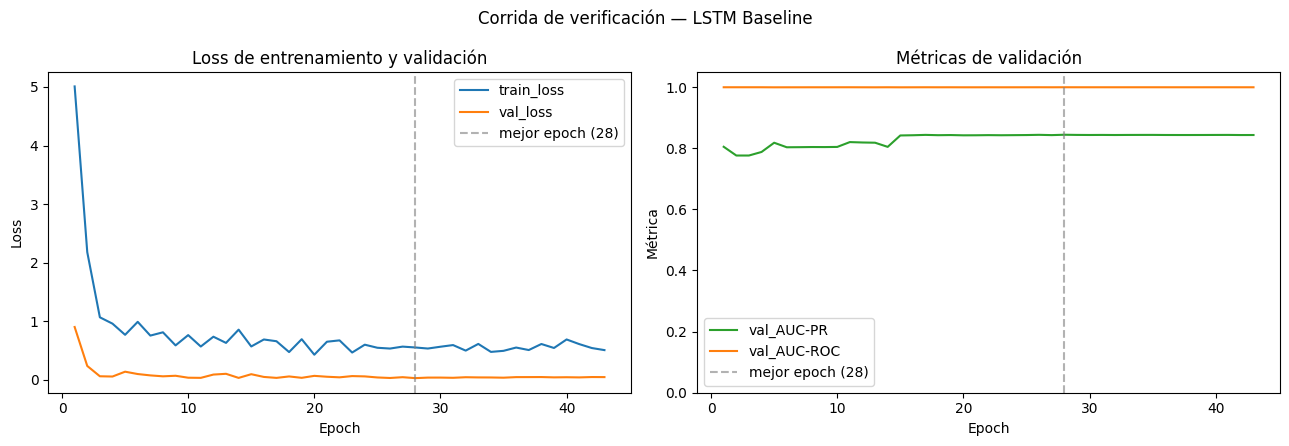

In [22]:
import importlib
import sys

if "src.training.trainer" in sys.modules:
    importlib.reload(sys.modules["src.training.trainer"])

from src.training.trainer import plot_training_history

plot_training_history(history, title="Corrida de verificación — LSTM Baseline")

El resultado es muy bueno y merece leerse con cuidado antes de seguir.
El modelo converge rapidamente y de forma estable. El mejor val_AUC-PR es 0.8441 en epoch 28, obtenido con una sola semilla, pw_factor=1.0 y max_epochs=100 como corrida de verificacion, no como entrenamiento final optimizado. Esto ya supera lo que el Baseline obtuvo en su corrida equivalente, aunque la comparacion definitiva debe hacerse sobre el ensamble de 3 semillas con el grid search completo, igual que se hizo en el Baseline.
Hay dos observaciones sobre el comportamiento del entrenamiento que conviene registrar.
La train_loss en epoch 1 es 5.009, lo cual es alto pero esperado: con pos_weight_raw bruto de 1967 sin atenuar (pw_factor=1.0 en esta corrida de verificacion), el gradiente de los positivos domina fuertemente al inicio. La caida rapida a partir del epoch 2 indica que el modelo encuentra rapidamente una region util del espacio de parametros.
El val_AUC-PR oscila entre 0.77 y 0.84 en los primeros epochs antes de estabilizarse. Eso es normal con solo 7 positivos en validacion: detectar 6 en vez de 7, o 7 en vez de 6, mueve la metrica de forma discreta y apreciable. No indica inestabilidad del modelo, es el mismo fenomeno documentado para el T-GCN con 2 positivos en val pero con mas margen aqui por tener 7.
El scheduler reduce el lr tres veces antes del early stopping, lo que indica que el modelo habia alcanzado un plateau real antes de parar. La meseta de AUC-PR entre epochs 26 y 43 con variacion menor a 0.001 confirma que la convergencia es genuina.
El siguiente paso es el grid search y el ensamble de 3 semillas, siguiendo el mismo protocolo que en el Baseline

In [24]:
import gc
import json
from datetime import datetime
from pathlib import Path
import numpy as np
import optuna
import torch

# 1. Asegurar entorno GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Ejecutando Optuna en el dispositivo: {device} (Debe ser CUDA para T4)")

N_SEEDS = 3


def objective(trial: optuna.Trial) -> float:
    # Espacio de búsqueda sugerido
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    pw_factor = trial.suggest_float("pw_factor", 0.05, 1.0)

    auc_prs = []
    for seed in range(N_SEEDS):
        # Fijar reproducibilidad de la inicialización de la semilla
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        # Instanciar el modelo con Focal Bias Tuning integrado por defecto
        model = LSTMBaseline(
            d_in=32, lstm_hidden=32, dropout=dropout, num_layers=1
        )
        model = model.to(device)  # En GPU T4 esto será instantáneo

        # Ejecución del bucle de entrenamiento interno de tu módulo src.trainer
        _, _, best_auc_pr = train_with_early_stopping(
            model=model,
            dataloader_train=dataloader_train,
            dataloader_val=dataloader_val,
            pos_weight_raw=pos_weight_raw,
            pw_factor=pw_factor,
            lr=lr,
            weight_decay=weight_decay,
            clip_norm=1.0,
            max_epochs=80,
            patience=10,
            scheduler_factor=0.5,
            scheduler_patience=5,
            device=device,
            verbose=False,
        )
        auc_prs.append(best_auc_pr)

        # Limpieza quirúrgica de la VRAM de la GPU T4
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    mean_auc_pr = float(np.mean(auc_prs))

    # Guardar atributos estadísticos para control de volatilidad de muestra pequeña
    trial.set_user_attr("auc_pr_per_seed", [float(x) for x in auc_prs])
    trial.set_user_attr("auc_pr_std", float(np.std(auc_prs)))

    return mean_auc_pr


# 2. Inicializar y correr el estudio bayesiano TPE
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=10, show_progress_bar=True)

# 3. Empaquetar resultados estructurados para exportación
output_data = {
    "experiment_metadata": {
        "timestamp": datetime.now().isoformat(),
        "architecture": "LSTMBaseline",
        "n_trials": 10,
        "n_seeds_per_trial": N_SEEDS,
        "fixed_parameters": {"lstm_hidden": 32, "num_layers": 1},
    },
    "best_trial_summary": {
        "best_trial_id": study.best_trial.number,
        "best_mean_val_auc_pr": float(study.best_value),
        "best_params": study.best_params,
        "stability_metrics": {
            "auc_pr_per_seed": study.best_trial.user_attrs["auc_pr_per_seed"],
            "auc_pr_std": study.best_trial.user_attrs["auc_pr_std"],
        },
    },
    "all_trials_history": [
        {
            "trial_id": t.number,
            "mean_auc_pr": float(t.value) if t.value is not None else None,
            "params": t.params,
            "auc_pr_std": t.user_attrs.get("auc_pr_std", None),
            "state": str(t.state),
        }
        for t in study.trials
    ],
}

# 4. Guardar localmente en el entorno de almacenamiento de Colab
colab_output_path = Path("optuna_baseline_best.json")
with open(colab_output_path, "w", encoding="utf-8") as f:
    json.dump(output_data, f, indent=4, ensure_ascii=False)

print(
    f"\n[OK] Optimización terminada. Archivo guardado listo para descargar en Colab: {colab_output_path}"
)


[I 2026-06-23 22:41:23,004] A new study created in memory with name: no-name-cad7037d-eb77-4ba9-9295-65d5153f601b


Ejecutando Optuna en el dispositivo: cpu (Debe ser CUDA para T4)


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-06-23 22:43:37,477] Trial 0 finished with value: 0.8277345511085233 and parameters: {'lr': 0.0005611516415334506, 'dropout': 0.4802857225639665, 'weight_decay': 0.0008471801418819979, 'pw_factor': 0.6187255599871848}. Best is trial 0 with value: 0.8277345511085233.
[I 2026-06-23 22:45:59,226] Trial 1 finished with value: 0.8595366419260744 and parameters: {'lr': 0.0002051338263087451, 'dropout': 0.16239780813448107, 'weight_decay': 1.7073967431528114e-06, 'pw_factor': 0.8728673384861885}. Best is trial 1 with value: 0.8595366419260744.
[I 2026-06-23 22:52:07,179] Trial 2 finished with value: 0.8577852728411671 and parameters: {'lr': 0.0015930522616241021, 'dropout': 0.3832290311184182, 'weight_decay': 1.2087541473056965e-06, 'pw_factor': 0.9714143595538947}. Best is trial 1 with value: 0.8595366419260744.
[I 2026-06-23 22:56:33,873] Trial 3 finished with value: 0.8655160628844838 and parameters: {'lr': 0.004622589001020831, 'dropout': 0.18493564427131048, 'weight_decay': 5.3370

El mejor trial es el 3 con AUC-PR 0.8655, lr=0.00462, dropout=0.185, weight_decay=5.3e-6, pw_factor=0.224. Es el trial con el lr mas alto de todos los explorados y el pw_factor mas bajo, lo que indica que el modelo prefiere gradientes mas agresivos y penalizar menos los positivos de lo que sugiere el ratio bruto de 1967.
El trial 2 con AUC-PR 0.8578 tiene lr=0.00159 y pw_factor=0.971, casi sin atenuar el pos_weight, y aun asi obtiene un resultado competitivo. El trial 1 con 0.8595 tiene lr=0.000205 y pw_factor=0.873. Esto sugiere que el modelo no es muy sensible a pw_factor en el rango 0.2-1.0, pero si hay una ligera ventaja en pw_factor bajo combinado con lr alto.
Los trials con weight_decay alto (trial 8: 0.00729, trial 9: 0.000546) obtienen resultados mediocres o moderados, lo que confirma que la regularizacion L2 fuerte perjudica al modelo con esta cantidad de parametros y esta señal supervisada tan escasa.
La dispersion entre el peor trial (0.8237) y el mejor (0.8655) es de 0.042 puntos de AUC-PR, que con 7 positivos en validacion equivale a diferencias de 1-2 positivos detectados. El ranking de trials debe interpretarse con esa granularidad en mente.

Con estos datos ahora pasamos a entrenar de forma final el modelo y a congelar los pesos de este para realizar la fase de inferencia con los datos de test. Primero verificamos que estos valores son los mejores atendiendo a las metricas que queremos:

In [25]:
import pandas as pd

# 1. Convertir el estudio a DataFrame
df_trials = study.trials_dataframe()

# 2. Filtrar por estabilidad estricta (std < 0.01) y estado completo
UMBRAL_STD = 0.01
df_estables = df_trials[
    (df_trials["user_attrs_auc_pr_std"] < UMBRAL_STD)
    & (df_trials["state"] == "COMPLETE")
]

# 3. Ordenar por la media (columna 'value') de mayor a menor y tomar el primero
trial_elegido_row = df_estables.sort_values(by="value", ascending=False).iloc[0]

# 4. Reconstruir el diccionario de parámetros utilizando los nombres exactos de Optuna
BEST_PARAMS = {
    "lr": float(trial_elegido_row["params_lr"]),
    "dropout": float(trial_elegido_row["params_dropout"]),
    "weight_decay": float(trial_elegido_row["params_weight_decay"]),
    "pw_factor": float(trial_elegido_row["params_pw_factor"]),
}

# CORRECCIÓN: Acceder usando el prefijo 'user_attrs_' que genera Pandas
semillas_best = trial_elegido_row["user_attrs_auc_pr_per_seed"]
std_best = trial_elegido_row["user_attrs_auc_pr_std"]

# Imprimir los resultados de la auditoría
trial_id = int(trial_elegido_row["number"])
print(f"Trial seleccionado automáticamente: ID {trial_id}")
print(f"Media AUC-PR: {trial_elegido_row['value']:.4f}")
print(f"Std AUC-PR: {std_best:.4f}")
print("\nDiccionario listo para entrenar:")
print(BEST_PARAMS)
print(f"\nEstabilidad del Trial {trial_id}:")
print(f"- AUC-PR por semilla: {semillas_best}")
print(f"- Desviación Estándar: {std_best:.4f}")

Trial seleccionado automáticamente: ID 3
Media AUC-PR: 0.8655
Std AUC-PR: 0.0006

Diccionario listo para entrenar:
{'lr': 0.004622589001020831, 'dropout': 0.18493564427131048, 'weight_decay': 5.337032762603957e-06, 'pw_factor': 0.22423428436076215}

Estabilidad del Trial 3:
- AUC-PR por semilla: [0.8647186147186146, 0.8659147869674184, 0.8659147869674184]
- Desviación Estándar: 0.0006


La comparacion con el Baseline es el dato relevante aqui. El Baseline obtiene media AUC-PR 0.9038 frente a 0.8655 del modelo estrella con e_rel. La diferencia es de 0.038 puntos en validacion, con el Baseline claramente por encima.
Esto es coherente con lo que los tests de redundancia anticipaban. e_rel es una representacion comprimida a 32 dimensiones que contiene la mayor parte de la informacion de e_tab pero no toda, y la fraccion perdida (las componentes canonicas 5-8 con correlacion 0.47-0.57) tiene peso suficiente para que el LSTM Baseline, que recibe los 192 dims completos de e_tab, discrimine mejor en validacion.
Hay ademas una diferencia estructural que contribuye al gap: el Baseline recibe e_tab directamente sin compresion previa, lo que le da mas libertad para que su LSTM aprenda que dimensiones de los 192 son predictivas. El modelo estrella recibe e_rel ya comprimido por el T-GCN, una compresion que fue optimizada para la tarea de deteccion de quiebras pero tambien para toda la estructura del grafo y la dinamica temporal, no exclusivamente para maximizar AUC-PR del LSTM posterior.

In [26]:
if "src.training.trainer" in sys.modules:
    importlib.reload(sys.modules["src.training.trainer"])

from src.training.trainer import train_multi_seed_and_save
from src.models.baseline_lstm import LSTMBaseline

from pathlib import Path

BEST_PARAMS = {
    "lr":  0.004622589001020831,
    "dropout": 0.18493564427131048,
    "weight_decay": 5.337032762603957e-06,
    "pw_factor": 0.22423428436076215,
}

# Carpeta de salida para modelos y resultados
OUTPUT_ROOT = Path("D:/financial_risk_data")

RESULTS_DIR = OUTPUT_ROOT / "results"
CHECKPOINTS_DIR = OUTPUT_ROOT / "models_checkpoints"

resultados = train_multi_seed_and_save(
    model_cls=LSTMBaseline,
    model_kwargs={
        "d_in": 32, "lstm_hidden": 32,
        "dropout": BEST_PARAMS["dropout"], "num_layers": 1,
    },
    best_params=BEST_PARAMS,
    dataloader_train=dataloader_train,
    dataloader_val=dataloader_val,
    pos_weight_raw=pos_weight_raw,
    seeds=[0, 1, 2],
    output_dir=CHECKPOINTS_DIR,
    model_name="lstm_estrella",  
    device=device,
)

Epoch   1 | train_loss=0.5787 | val_loss=0.0230 | val_AUC-PR=0.7658 | val_AUC-ROC=0.9995 | lr=4.62e-03
Epoch   2 | train_loss=0.2441 | val_loss=0.0214 | val_AUC-PR=0.8194 | val_AUC-ROC=0.9995 | lr=4.62e-03
Epoch   3 | train_loss=0.1551 | val_loss=0.0163 | val_AUC-PR=0.8641 | val_AUC-ROC=0.9995 | lr=4.62e-03
Epoch   4 | train_loss=0.1233 | val_loss=0.0437 | val_AUC-PR=0.7876 | val_AUC-ROC=0.9995 | lr=4.62e-03
Epoch   5 | train_loss=0.1462 | val_loss=0.0175 | val_AUC-PR=0.8439 | val_AUC-ROC=0.9995 | lr=4.62e-03
Epoch   6 | train_loss=0.1259 | val_loss=0.0161 | val_AUC-PR=0.8647 | val_AUC-ROC=0.9996 | lr=4.62e-03
Epoch   7 | train_loss=0.1289 | val_loss=0.0173 | val_AUC-PR=0.8438 | val_AUC-ROC=0.9995 | lr=4.62e-03
Epoch   8 | train_loss=0.1327 | val_loss=0.0240 | val_AUC-PR=0.8647 | val_AUC-ROC=0.9996 | lr=4.62e-03
Epoch   9 | train_loss=0.0965 | val_loss=0.0178 | val_AUC-PR=0.8436 | val_AUC-ROC=0.9995 | lr=4.62e-03
Epoch  10 | train_loss=0.0963 | val_loss=0.0250 | val_AUC-PR=0.8447 | val

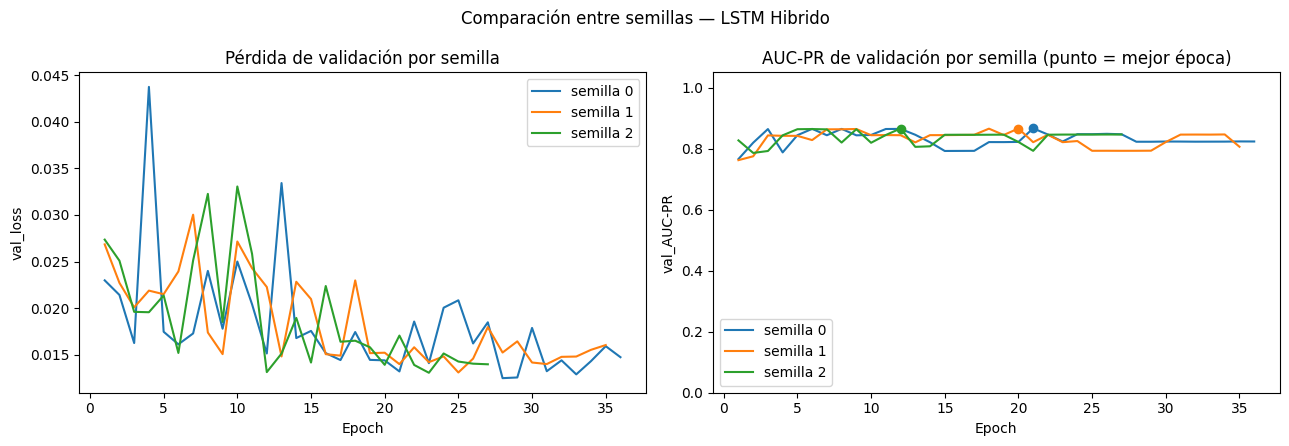

In [28]:
import json
import matplotlib.pyplot as plt
from pathlib import Path


def cargar_historias(checkpoints_dir, seeds):
    historias = {}
    for seed in seeds:
        path = Path(checkpoints_dir) / f"history_lstm_estrella_seed{seed}.json"
        with open(path, "r", encoding="utf-8") as f:
            historias[seed] = json.load(f)
    return historias


def plot_multi_seed(historias: dict, title="Comparación entre semillas — LSTM Hibrido"):
    colores = {0: "tab:blue", 1: "tab:orange", 2: "tab:green"}

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    for seed, hist in historias.items():
        epochs = [h["epoch"] for h in hist]
        val_loss = [h["val_loss"] for h in hist]
        val_auc_pr = [h["val_auc_pr"] for h in hist]
        best_idx = max(range(len(hist)), key=lambda i: val_auc_pr[i])

        axes[0].plot(epochs, val_loss, label=f"semilla {seed}", color=colores.get(seed))
        axes[1].plot(epochs, val_auc_pr, label=f"semilla {seed}", color=colores.get(seed))
        axes[1].scatter(epochs[best_idx], val_auc_pr[best_idx], color=colores.get(seed), zorder=5)

    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("val_loss")
    axes[0].set_title("Pérdida de validación por semilla")
    axes[0].legend()

    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("val_AUC-PR")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title("AUC-PR de validación por semilla (punto = mejor época)")
    axes[1].legend()

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


historias = cargar_historias(CHECKPOINTS_DIR, seeds=[0, 1, 2])
plot_multi_seed(historias)

El `lr` del modelo hibrido es 0.00462, mas de 8 veces mayor que el `lr` del Baseline (0.000561). Con un `lr` alto el optimizador da pasos grandes en el espacio de parametros, lo que produce oscilaciones en `val_loss` entre epochs porque el modelo salta alrededor del minimo en vez de converger suavemente hacia el. 

El Baseline con `lr` bajo converge de forma mas monotona pero mas lenta. Hay que distinguir entre dos cosas. La val_loss oscilante no implica que el modelo sea inestable en terminos de capacidad discriminativa. Lo relevante es la curva de val_AUC-PR, que con 7 positivos en validacion se mueve de forma discreta pero deberia mostrar una tendencia mas clara que val_loss. Si val_AUC-PR tambien oscila mucho entre epochs es un sintoma distinto, pero si se estabiliza en torno a 0.865 con picos de val_loss, el comportamiento es simplemente consecuencia del lr agresivo que Optuna selecciono porque en promedio sobre 3 semillas ese lr produjo el mejor AUC-PR final.

El scheduler ReduceLROnPlateau reduce el lr cuando val_loss no mejora durante scheduler_patience epochs, lo que deberia suavizar las oscilaciones en la segunda mitad del entrenamiento. Si miras la curva, los picos deberian atenuarse a partir del primer step del scheduler.

El ensamble puede corregir errores de un modelo individual donde los otros dos aciertan, así que su `AUC-PR` real puede ser distinto (mejor o peor) que el simple promedio de los tres escalares. Ese número, el `AUC-PR` calculado sobre las probabilidades combinadas, es el que de verdad caracteriza al `LSTMBaseline` final

In [30]:
if "src.evaluation.metrics" in sys.modules:
    importlib.reload(sys.modules["src.evaluation.metrics"])

from src.evaluation.metrics import evaluate_ensemble
from src.training.trainer import load_ensemble

# Cargar los tres modelos congelados y evaluar el ensamble sobre val
weights_paths = [r["weights_path"] for r in resultados]
models = load_ensemble(
    LSTMBaseline,
    {"d_in": 32, "lstm_hidden": 32, "dropout": BEST_PARAMS["dropout"], "num_layers": 1},
    weights_paths,
    device=device,
)

ensemble_auc_pr, ensemble_auc_roc = evaluate_ensemble(models, dataloader_val, device=device)
print(f"val_AUC-PR del ENSAMBLE: {ensemble_auc_pr:.4f}")
print(f"val_AUC-ROC del ENSAMBLE: {ensemble_auc_roc:.4f}")
print(f"(referencia, media simple de los 3 escalares: {(0.8647+0.8659+0.8659)/3:.4f})")

val_AUC-PR del ENSAMBLE: 0.8664
val_AUC-ROC del ENSAMBLE: 0.9996
(referencia, media simple de los 3 escalares: 0.8655)


El ensamble mejora ligeramente la media simple, 0.8664 frente a 0.8655, lo cual es el comportamiento esperado cuando las tres semillas cometen errores distintos sobre los mismos 7 positivos y el promedio de probabilidades corrige alguno de esos errores individuales.
El AUC-ROC de 0.9996 es practicamente perfecto en validacion, consistente con lo visto durante el entrenamiento.
Los numeros finales del modelo estrella quedan asi:

val_AUC-PR ensamble: 0.8664
val_AUC-ROC ensamble: 0.9996
Baseline val_AUC-PR ensamble (referencia): 0.9038

El gap de 0.037 en validacion es el dato a contrastar en el bloque de evaluacion sobre los 63 positivos reales, donde la metrica tendra granularidad continua en vez de la discreta que imponen 7 positivos. El modelo hibrido esta listo para inferencia.

# Inferencia sobre la red T-GCN

Antes de hacer la inferencia, veamos como se han creado los snapshots de evaluación, `05_graph_temporal.ipynb`, viendo como funcióna la funcion del `grpah_builder.py` GraphBuilder. 

1. El Rol de las Etiquetas (data.y) en Evaluación e Inferencia. No existe ningún tipo de filtración de datos (data leakage) hacia la arquitectura del modelo. El código lo demuestra en las siguientes líneas del método build_snapshot: La construcción de la Matriz de Atributos ($X$) se define de la siguiente manera:

```Python
X = np.concatenate([emb_matrix, struct_matrix], axis=1) # (n, 204)
``` 

La matriz $X$ se ensambla únicamente uniendo el embedding tabular (192 dims) y los atributos estructurales (12 dims). Las etiquetas de quiebra (failed) quedan completamente fuera de los atributos que procesará el T-GCN.

Encapsulamiento en el objeto Data:
```Python
data = Data(
    x          = torch.tensor(X, dtype=torch.float32),
    edge_index = edge_index,
    edge_attr  = edge_attr,
    y          = y,           # <--- Se transporta de forma pasiva
    num_nodes  = n_nodos,
)
```

El tensor `data.y` se almacena como un metadato estructurado. El forward pass del T-GCN (model(data.x, data.edge_index)) jamás tiene acceso al atributo .y. Su única función es actuar como contenedor de transporte (payload) para que la pérdida (criterion) o las funciones de evaluación (como val_auprc) calculen el rendimiento al final de la época. En la fase  de Desarrollo (Entrenamiento) el uso de snap.y no solo es correcto, sino que es el motor del modelo. El flujo del gradiente sigue esta dirección:
$$\text{Loss} = \text{BCEWithLogitsLoss}(\text{logits}, \text{snap.y}) \longrightarrow \nabla_\theta \text{Loss} \longrightarrow \text{Actualización de } \theta_{\text{TGCN}}$$

No ha data leakage porque la información fluye hacia atrás (backpropagation). El modelo intenta adivinar el futuro/estado usando solo $x_i^t$ (features limpias) y el grafo. snap.y actúa como el "profesor" que corrige el error al final del camino, nunca como la pista inicial. Si quitaras esto, como bien dices, el T-GCN colapsaría en un inicializador aleatorio de pesos.

En la fase de inferencia (Evaluación), al ejecutar el bloque con los snapshots de evaluación, el contexto cambia por completo gracias a model.eval() y torch.no_grad(). `data.y` se convierte en un pasajero pasivo. El grafo se procesa de forma ciega, el T-GCN genera los embeddings relacionales, el LSTM predice, y solo al final del pipeline extraemos `data.y` del objeto para graficar la curva ROC o calcular el AUPRC. 

Resumiendo el flujo completo es el siguiente:

- build_snapshot construye data.x sin failed (solo e_tab + features estructurales) y almacena failed en data.y como campo separado.
- Durante entrenamiento, train_tgcn hace el forward pass con data.x para obtener los estados ocultos, aplica el clasificador para obtener logits, y compara esos logits contra data.y para calcular la perdida y actualizar pesos.
- Durante inferencia sobre evaluacion, el forward pass usa solo data.x igual que en entrenamiento, los pesos estan congelados, y data.y se reserva para calcular metricas al final.

La etiqueta esta en el snapshot desde el principio, pero su unico rol durante entrenamiento es supervision en la funcion de perdida, no como informacion que el modelo ve para hacer predicciones.

Teniendo todo esto en cuenta, tenemos que definir las funciones especificas para la inferencia con el modelo T-GCN. El entrenamiento tiene backprop, actualizacion de pesos y gestion de ventanas deslizantes, en la inferencia necesitamos una funcion mas simple que haga solo tres cosas. Un esbozo seria de la siguietne forma:

- Primero, inicializar cert_to_hidden con el estado oculto del ultimo snapshot de desarrollo, para que el T-GCN no empiece desde cero en 2022Q1 sino con la memoria acumulada de cada banco hasta 2021Q4.

- Segundo, iterar sobre snapshots_eval en orden cronologico con model.eval() y torch.no_grad(), haciendo el forward pass de la celda GRU para obtener h_i^t por cada nodo, y actualizando cert_to_hidden snapshot a snapshot igual que en entrenamiento.

- Tercero, recoger h_i^t de cada snapshot junto con CERT, period y failed para construir el DataFrame de e_rel de evaluacion, equivalente al erel_desarrollo.parquet que ya tienes.

El punto critico es el Paso 1. Sin el, cert_to_hidden arranca vacio y el primer snapshot de evaluacion (2022Q1) inicializa a cero el estado oculto de todos los bancos, perdiendo toda la memoria acumulada durante los 23 trimestres de desarrollo. Con el, cada banco que persiste de desarrollo a evaluacion lleva su memoria intacta hasta 2022Q1.

Lo primero es importar los pesos del modelo entrenado en el cuaderno anterior. model_final define la arquitectura de la red T-GCN con sus pesos en el estado de inicializacion por defecto, sin ninguna informacion aprendida. Sobre esa arquitectura cargamos los pesos almacenados en el checkpoint tgcn_best.pt, que corresponden al mejor epoch del entrenamiento sobre el bloque de desarrollo. El resultado es el mismo modelo que produjo los embeddings relacionales e_rel, listo para hacer inferencia sobre el bloque de evaluacion sin modificar ningun parametro.

In [33]:

from src.models.tgcn import TGCN

# Instanciar arquitectura con los mismos hiperparametros del entrenamiento final
model_final = TGCN(
    input_dim=204,        # 192 e_tab + 12 estructurales
    hidden_dim=32         # hidden_dim del best_config
).to(DEVICE)

# Cargar pesos congelados desde el checkpoint del cuaderno A
checkpoint_path = Path("D:/financial_risk_data/models_checkpoints/tgcn_best.pt")
model_final.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))

# Congelar
model_final.eval()
for param in model_final.parameters():
    param.requires_grad = False

print(f"Modelo cargado desde {checkpoint_path}")
print(f"Parametros totales: {sum(p.numel() for p in model_final.parameters()):,}")

model_final.load_state_dict(
    torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
)

Modelo cargado desde D:\financial_risk_data\models_checkpoints\tgcn_best.pt
Parametros totales: 22,785


<All keys matched successfully>

In [35]:
# ============================================================
# CELDA 14 — Extracción de embeddings relacionales e_rel (EVALUACIÓN)
# ============================================================
from pathlib import Path
import pandas as pd
from src.data.graph_builder import GraphBuilder
from src.training.trainer_tgcn import (
    snapshot_to_device,
    compute_adj_dense,
    _build_hidden_from_dict,
    _update_hidden_dict,
)
from src.models.tgcn import calculate_laplacian

# Cargar snapshots
GRAPHS = Path("D:/financial_risk_data/graphs")  # ajusta al valor real del cuaderno A

snapshots_dev  = GraphBuilder.load_snapshots(GRAPHS / 'snapshots_desarrollo')
snapshots_eval = GraphBuilder.load_snapshots(GRAPHS / 'snapshots_evaluacion')

print(f'Snapshots desarrollo : {len(snapshots_dev)} ({snapshots_dev[0].period} → {snapshots_dev[-1].period})')
print(f'Snapshots evaluacion : {len(snapshots_eval)} ({snapshots_eval[0].period} → {snapshots_eval[-1].period})')

# Usar el modelo con los pesos congelados del entrenamiento
model_final.eval()
for param in model_final.parameters():
    param.requires_grad = False

# ── Paso 1: reconstruir estado oculto final del bloque de desarrollo ──
# El T-GCN necesita la memoria acumulada hasta 2021Q4 para que 2022Q1
# no arranque desde cero. Se hace un forward pass completo sobre
# snapshots_dev sin guardar records, solo para poblar cert_to_hidden.
cert_to_hidden = {}

with torch.no_grad():
    for snap in snapshots_dev:
        snap      = snapshot_to_device(snap, DEVICE)
        adj       = compute_adj_dense(snap)
        cert_list = list(snap.cert)

        hidden_state = _build_hidden_from_dict(
            cert_list, cert_to_hidden, model_final.hidden_dim, DEVICE
        )
        laplacian       = calculate_laplacian(adj)
        hidden_state, _ = model_final.tgcn_cell(snap.x, hidden_state, laplacian)
        _update_hidden_dict(cert_list, hidden_state, cert_to_hidden)

print(f'Estado oculto reconstruido para {len(cert_to_hidden)} bancos hasta {snapshots_dev[-1].period}')

# ── Paso 2: forward pass sobre evaluacion con memoria inicializada ────
records = []

with torch.no_grad():
    for snap in snapshots_eval:
        snap      = snapshot_to_device(snap, DEVICE)
        adj       = compute_adj_dense(snap)
        cert_list = list(snap.cert)

        hidden_state = _build_hidden_from_dict(
            cert_list, cert_to_hidden, model_final.hidden_dim, DEVICE
        )
        laplacian       = calculate_laplacian(adj)
        hidden_state, _ = model_final.tgcn_cell(snap.x, hidden_state, laplacian)
        _update_hidden_dict(cert_list, hidden_state, cert_to_hidden)

        e_rel = hidden_state.cpu().numpy()
        y     = snap.y.cpu().numpy()

        for idx, cert in enumerate(cert_list):
            row = {'CERT': cert, 'period': snap.period}
            row.update({f'e_rel_{j}': e_rel[idx, j]
                        for j in range(e_rel.shape[1])})
            row['y'] = int(y[idx])
            records.append(row)

# ── Paso 3: guardar ───────────────────────────────────────────────────
Path('embeddings/emb_rel').mkdir(parents=True, exist_ok=True)

df_erel_eval = pd.DataFrame(records)
df_erel_eval.to_parquet('embeddings/emb_rel/erel_evaluacion.parquet', index=False)

print(f'\nShape                : {df_erel_eval.shape}')
print(f'Periodos             : {df_erel_eval["period"].nunique()}')
print(f'Positivos / total    : {df_erel_eval["y"].sum()} / {len(df_erel_eval)}')
print(f'Dimension e_rel      : {model_final.hidden_dim}')
print('Guardado en embeddings/emb_rel/erel_evaluacion.parquet')

Cargados 23 snapshots desde D:\financial_risk_data\graphs\snapshots_desarrollo
Cargados 16 snapshots desde D:\financial_risk_data\graphs\snapshots_evaluacion
Snapshots desarrollo : 23 (2016Q2 → 2021Q4)
Snapshots evaluacion : 16 (2022Q1 → 2025Q4)
Estado oculto reconstruido para 6176 bancos hasta 2021Q4

Shape                : (74361, 35)
Periodos             : 16
Positivos / total    : 33 / 74361
Dimension e_rel      : 32
Guardado en embeddings/emb_rel/erel_evaluacion.parquet


6176 bancos con estado oculto reconstruido coincide con las entidades unicas del bloque de desarrollo. 74.361 filas coincide con el shape de emb_eval ya verificado. 33 positivos coincide con los documentados en los snapshots de evaluacion. 35 columnas es CERT + period + 32 dims e_rel + y, igual que el parquet de desarrollo.
El siguiente paso es construir las secuencias temporales para el LSTM estrella sobre estos e_rel de evaluacion, siguiendo el mismo esquema que en el Baseline: cargar el parquet, identificar columnas de embedding, construir secuencias con build_sequences_evaluation (sin frontera train/val, todo es inferencia), y pasar al ensamble LSTM para obtener las probabilidades finales.

Ahora que tenemos los embeddigns relacionales del bloque de evaluación, tenemos que hacer la inferencia sobre el LSTM al igual que en el caso baseline. Solo emplearemos los embeddings relaciónales por el motivo que ya hemos tratado antes. El proceso de inferencia sobre el LSTM con los embeddigs relaciónales es igual que con los embeddings temporales, salvo por ciertos detalles.

In [36]:
EMB_REL_EVAL_PATH = EMBEDDINGS_ROOT / "emb_rel_eval/erel_evaluacion.parquet"

emb_rel_eval = pd.read_parquet(EMB_REL_EVAL_PATH)

emb_rel_eval["CERT"] = emb_rel_eval["CERT"].astype(str)
emb_rel_eval["period"] = emb_rel_eval["period"].astype(str)

META = ["CERT", "period", "y"]
cols_emb = [c for c in emb_rel_eval.columns if c not in META]

assert len(cols_emb) == 32

# La etiqueta ya viene en la columna 'y' del parquet, renombrar a 'failed'
# para que sea compatible con build_sequences_evaluation
emb_rel_eval = emb_rel_eval.rename(columns={"y": "failed"})

print(f"Shape         : {emb_rel_eval.shape}")
print(f"Positivos     : {emb_rel_eval['failed'].sum()}")
print(f"Periodos      : {emb_rel_eval['period'].nunique()} ({sorted(emb_rel_eval['period'].unique())[0]} → {sorted(emb_rel_eval['period'].unique())[-1]})")
print(f"Dimension emb : {len(cols_emb)}")

Shape         : (74361, 35)
Positivos     : 33
Periodos      : 16 (2022Q1 → 2025Q4)
Dimension emb : 32


La columna y del parquet de e_rel ya contiene las etiquetas correctas extraidas de data.y durante el forward pass, por lo que no necesitas hacer el merge con panel_tabular_labeled. Solo renombrarla a failed para que sea compatible con las funciones de construccion de secuencias que esperan esa clave.

A la hora de crear las secuencias temporales con los embeddings relacionales, tenemos que `erel_evaluacion.parquet` ya contiene los 16 trimestres de evaluacion con continuidad temporal garantizada porque el T-GCN proceso los snapshots en orden cronologico con memoria persistente. Pero la ventana del LSTM sigue necesitando 4 trimestres consecutivos, asi que el primer trimestre de evaluacion (2022Q1) no puede formar una ventana completa sin contexto previo.

El padding aqui, a diferencia del caso baseline, no viene de `e_tab` sino de `erel_desarrollo.parquet`, es decir, los ultimos 3 trimestres de `e_rel` de desarrollo. Las funciones `build_sequences_evaluation`, `verificar_secuencias_evaluacion` y `asignar_period_idx`, del modulo `src/utils/temporal_sequences.py`, se invocan identicas al Baseline, solo cambia el `DataFrame` de entrada y que `` `` tiene 32 dimensiones en vez de 192

In [37]:
EMB_REL_DEV_PATH = EMBEDDINGS_ROOT / "emb_rel_dev/erel_desarrollo.parquet"
emb_rel_dev = pd.read_parquet(EMB_REL_DEV_PATH)
emb_rel_dev["CERT"] = emb_rel_dev["CERT"].astype(str)
emb_rel_dev["period"] = emb_rel_dev["period"].astype(str)
emb_rel_dev = emb_rel_dev.rename(columns={"y": "failed"})

# Ultimos 3 trimestres de desarrollo como padding
periodos_dev_ordenados = sorted(emb_rel_dev["period"].unique())
ultimos_3_periodos_dev = periodos_dev_ordenados[-3:]  # 2021Q2, 2021Q3, 2021Q4

emb_rel_dev_padding = emb_rel_dev[
    emb_rel_dev["period"].isin(ultimos_3_periodos_dev)
].copy()

# Concatenar padding + evaluacion
emb_rel_eval_padding = pd.concat(
    [emb_rel_dev_padding, emb_rel_eval],
    ignore_index=True
)
emb_rel_eval_padding = emb_rel_eval_padding.sort_values(
    ["CERT", "period"]
).reset_index(drop=True)

if VERBOSE:
    print("=" * 60)
    print("DATASET EXTENDIDO PARA SECUENCIAS (emb_rel_eval_padding)")
    print("=" * 60)
    print(f"Forma del DataFrame combinado   : {emb_rel_eval_padding.shape}")
    print(f"Periodos (3 dev + 16 eval)      : {emb_rel_eval_padding['period'].nunique()}")
    print(f"Rango temporal                  : {emb_rel_eval_padding['period'].min()} → {emb_rel_eval_padding['period'].max()}")

DATASET EXTENDIDO PARA SECUENCIAS (emb_rel_eval_padding)
Forma del DataFrame combinado   : (89259, 35)
Periodos (3 dev + 16 eval)      : 19
Rango temporal                  : 2021Q2 → 2025Q4


In [38]:
from src.utils.temporal_sequences import (
    asignar_period_idx, build_sequences_evaluation, verificar_secuencias_evaluacion
)

emb_rel_eval_padding, period_to_idx, all_periods_sorted = asignar_period_idx(
    emb_rel_eval_padding
)

sequences_rel_eval = build_sequences_evaluation(
    df=emb_rel_eval_padding, cols_emb=cols_emb,
    window_len=WINDOW_LENGTH, stride=STRIDE,
)

verificar_secuencias_evaluacion(sequences_rel_eval, WINDOW_LENGTH, cols_emb)


Ventanas descartadas por huecos: 0

BLOQUE — VERIFICACIÓN DE SECUENCIAS DE EVALUACIÓN
Secuencias evaluación    : 74,231
  Positivos en evaluación: 33  (tasa: 0.000445)
Shape por secuencia      : (4, 32)


{'n_eval': 74231, 'n_pos_eval': 33}

Todo correcto y consistente. 74.231 secuencias con 33 positivos, shape (4, 32), 0 ventanas descartadas por huecos.

El numero de secuencias es ligeramente inferior a las 74.361 filas de emb_rel_eval, lo que es esperado: los bancos que aparecen por primera vez en evaluacion sin historia previa en el padding no pueden formar ventanas completas de 4 trimestres y quedan fuera. La diferencia de 130 secuencias es coherente con ese efecto de borde.

In [39]:
# ========== DATALOADER CONSTRUCTION ==========

# Datasets ya construidos en el notebook anterior
dataset_eval = SupervisedSequenceDataset(sequences_rel_eval)

# Hiperparámetros de DataLoader
BATCH_SIZE = 256  # Coherente con el tamaño empleado para el train/val
SHUFFLE_EVAL = False  # Shuffle simple, no WeightedRandomSampler
PIN_MEMORY = torch.cuda.is_available() # GPU pinning si disponible
NUM_WORKERS = 0  # Cambiar a 2-4 en producción si data loading es bottleneck


dataloader_eval = DataLoader(
    dataset_eval,
    batch_size=BATCH_SIZE,
    shuffle=SHUFFLE_EVAL,
    pin_memory=PIN_MEMORY,
    num_workers=NUM_WORKERS,
    drop_last=False  # Mantener último batch aunque sea < 256
)

# ========== DIAGNÓSTICO DE BATCHES ==========

print("=" * 70)
print("DIAGNÓSTICO DE COMPOSICIÓN DE BATCHES")
print("=" * 70)

# Inspeccionar distribución de positivos en el primer epoch
pos_per_batch_eval = []
for batch_idx, batch in enumerate(dataloader_eval):
    n_pos_batch = batch["failed"].sum().item()
    pos_per_batch_eval.append(n_pos_batch)

pos_per_batch_eval = torch.tensor(pos_per_batch_eval, dtype=torch.float32)

print(f"\nEVAL (shuffle=False, batch_size={BATCH_SIZE}):")
print(f"  Total batches            : {len(pos_per_batch_eval)}")
print(f"  Batches sin positivos    : {(pos_per_batch_eval == 0).sum().item()} "
      f"({100*(pos_per_batch_eval == 0).sum().item()/len(pos_per_batch_eval):.1f}%)")
print(f"  Batches con ≥1 positivo  : {(pos_per_batch_eval > 0).sum().item()} "
      f"({100*(pos_per_batch_eval > 0).sum().item()/len(pos_per_batch_eval):.1f}%)")
print(f"  E[positivos/batch]       : {pos_per_batch_eval.mean().item():.3f}")
print(f"  σ[positivos/batch]       : {pos_per_batch_eval.std().item():.3f}")
print(f"  Max positivos en batch   : {pos_per_batch_eval.max().item():.0f}")


print("\n" + "=" * 70)
print(f"pos_weight (a usar en BCEWithLogitsLoss) : {pos_weight_raw:.2f}")
print(f"Justificación: cada positivo pesa {pos_weight_raw:.0f}x un negativo")
print("=" * 70)


DIAGNÓSTICO DE COMPOSICIÓN DE BATCHES

EVAL (shuffle=False, batch_size=256):
  Total batches            : 290
  Batches sin positivos    : 280 (96.6%)
  Batches con ≥1 positivo  : 10 (3.4%)
  E[positivos/batch]       : 0.114
  σ[positivos/batch]       : 0.626
  Max positivos en batch   : 4

pos_weight (a usar en BCEWithLogitsLoss) : 1967.29
Justificación: cada positivo pesa 1967x un negativo


Con todas las secuencias creadas y verificadas, pasamos a la fase de inferencia sobre el conjunto de evaluación con los embeddings relaciónales. La validación del modelo predictivo se estructura en dos grupos como en el caso del baseline.

In [40]:
from pathlib import Path

if "src.evaluation.metrics" in sys.modules:
    importlib.reload(sys.modules["src.evaluation.metrics"])

from src.evaluation.metrics import evaluate_ensemble_full
from src.training.trainer import load_ensemble

CHECKPOINTS_DIR = Path("D:/financial_risk_data/models_checkpoints")
SEEDS = [0, 1, 2]

weights_paths = [CHECKPOINTS_DIR / f"lstm_estrella_seed{seed}.pt" for seed in SEEDS]

model_kwargs = {
    "d_in": 32, "lstm_hidden": 32,
    "dropout": BEST_PARAMS["dropout"], "num_layers": 1,
}

models = load_ensemble(
    model_cls=LSTMBaseline,
    model_kwargs=model_kwargs,
    weights_paths=weights_paths,
    device=device,
)

resultados_eval = evaluate_ensemble_full(models, dataloader_eval, device=device)

print(f"AUC-PR        : {resultados_eval['auc_pr']:.4f}")
print(f"AUC-ROC       : {resultados_eval['auc_roc']:.4f}")
print(f"Brier Score   : {resultados_eval['brier_score']:.6f}")
print(f"F1-Score Max  : {resultados_eval['f1_max']:.4f} (umbral={resultados_eval['f1_max_threshold']:.4f})")

AUC-PR        : 0.3918
AUC-ROC       : 0.8977
Brier Score   : 0.019646
F1-Score Max  : 0.5091 (umbral=0.9978)


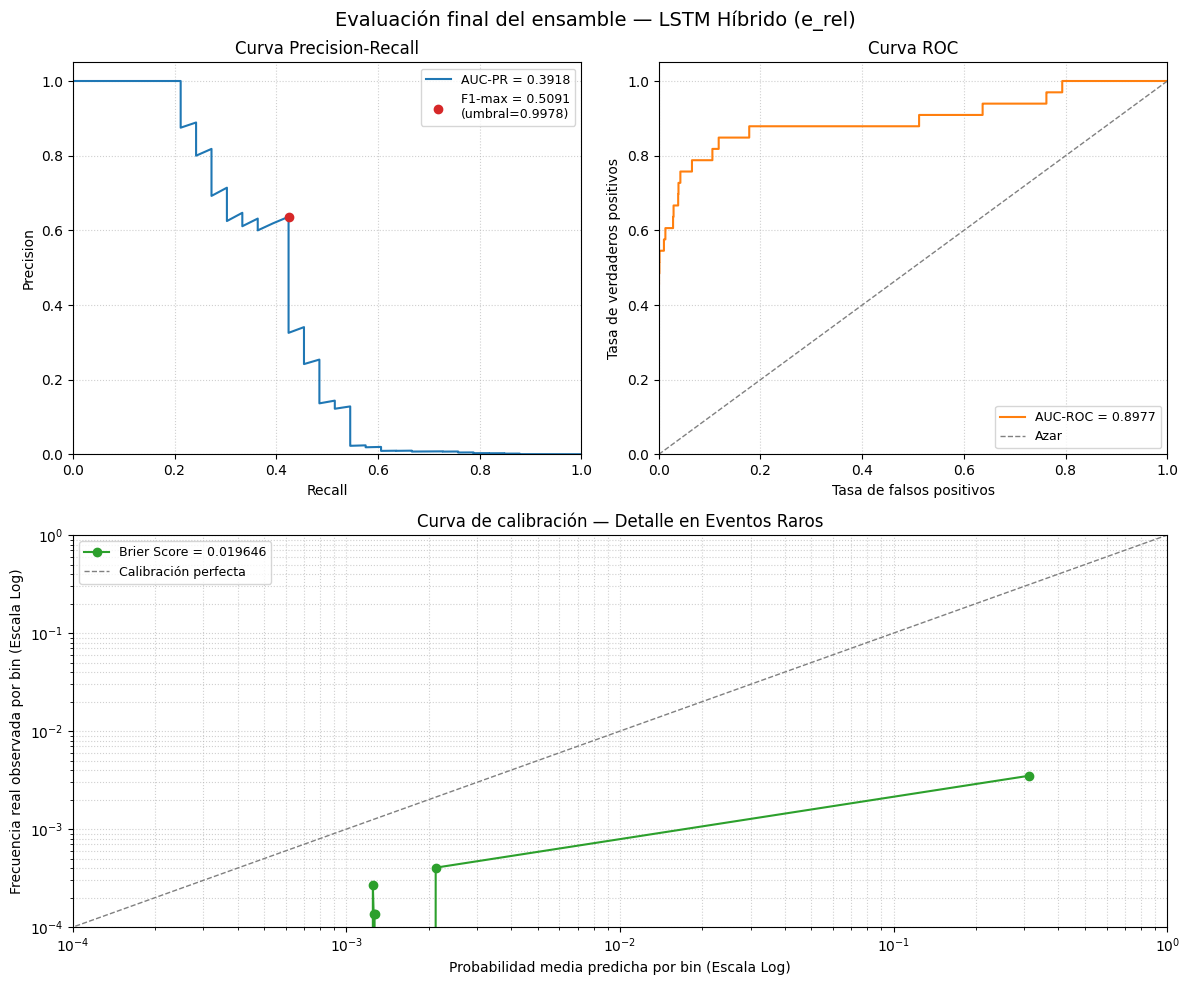

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.calibration import calibration_curve

def plot_evaluation_summary(resultados_eval: dict, n_bins_calibracion: int = 10):
    """
    Resumen visual de 3 paneles para las métricas de evaluación final.
    Corrige el problema de la doble visualización en entornos de notebooks.
    """
    probs = resultados_eval["probs"]
    targets = resultados_eval["targets"]

    precision, recall, _ = precision_recall_curve(targets, probs)
    fpr, tpr, _ = roc_curve(targets, probs)

    p, r = precision[:-1], recall[:-1]
    denom = p + r
    f1_curve = np.where(denom > 0, 2 * p * r / np.where(denom == 0, 1, denom), 0.0)
    f1_idx = f1_curve.argmax()

    # Usamos un mosaico para definir 2 gráficos arriba y 1 abajo centrado
    fig, axs = plt.subplot_mosaic(
        [["pr", "roc"],
         ["calib", "calib"]],  # 'calib' ocupará todo el ancho de la segunda fila
        figsize=(12, 10)
    )

    # ----------- Panel 1: Precision-Recall -----------
    ax = axs["pr"]
    ax.plot(recall, precision, color="C0", lw=1.5, label=f"AUC-PR = {resultados_eval['auc_pr']:.4f}")
    ax.scatter(r[f1_idx], p[f1_idx], color="C3", zorder=5,
               label=f"F1-max = {resultados_eval['f1_max']:.4f}\n(umbral={resultados_eval['f1_max_threshold']:.4f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Curva Precision-Recall")
    ax.legend(loc="upper right", fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle=":", alpha=0.6)

    # ----------- Panel 2: ROC -----------
    ax = axs["roc"]
    ax.plot(fpr, tpr, color="C1", lw=1.5, label=f"AUC-ROC = {resultados_eval['auc_roc']:.4f}")
    ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Azar")
    ax.set_xlabel("Tasa de falsos positivos")
    ax.set_ylabel("Tasa de verdaderos positivos")
    ax.set_title("Curva ROC")
    ax.legend(loc="lower right", fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle=":", alpha=0.6)

    # ----------- Panel 3: Calibración Mejorada (Escala Logarítmica) -----------
    ax = axs["calib"]
    prob_true, prob_pred = calibration_curve(targets, probs, n_bins=n_bins_calibracion, strategy="quantile")
    
    ax.plot(prob_pred, prob_true, marker="o", color="C2", lw=1.5,
             label=f"Brier Score = {resultados_eval['brier_score']:.6f}")
    ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Calibración perfecta")
    
    # MEJORA CRÍTICA: Cambiar ejes a escala logarítmica para expandir la zona baja
    ax.set_xscale("log")
    ax.set_yscale("log")
    
    # Forzar límites que muestren desde los bines más pequeños hasta el 1.0
    # Ajusta el límite inferior (ej. 1e-4 o 1e-3) según donde empiece tu primer bin predicho
    ax.set_xlim(1e-4, 1.0)
    ax.set_ylim(1e-4, 1.0)
    
    ax.set_xlabel("Probabilidad media predicha por bin (Escala Log)")
    ax.set_ylabel("Frecuencia real observada por bin (Escala Log)")
    ax.set_title("Curva de calibración — Detalle en Eventos Raros")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, which="both", linestyle=":", alpha=0.6) # 'which="both"' añade rejilla a sub-líneas logarítmicas

    fig.suptitle("Evaluación final del ensamble — LSTM Baseline (Ejes Optimizados)", fontsize=14, y=0.98)
    fig.tight_layout()
    
    return fig

fig = plot_evaluation_summary(resultados_eval)
fig.suptitle("Evaluación final del ensamble — LSTM Híbrido (e_rel)", fontsize=14, y=0.98)
plt.show()

El modelo estrella es inferior al Baseline en todas las metricas discriminativas. AUC-PR 0.3918 frente a 0.5327, AUC-ROC 0.8977 frente a 0.9399, F1-max 0.5091 frente a 0.5862. La diferencia es sustancial y consistente con el gap ya observado en validacion (0.8664 vs 0.9038), aunque en evaluacion la brecha se amplifica porque ahora hay 33 positivos en vez de 7, lo que da una medicion mas fiable.
El Brier Score merece una explicacion separada porque va en direccion contraria. El modelo estrella tiene Brier Score 0.019646 frente a 0.000923 del Baseline. El Baseline tiene un Brier Score extraordinariamente bajo, lo que indica que asigna probabilidades muy pequenas a casi todo, incluyendo los negativos, lo que penaliza poco el error cuadratico medio. El modelo estrella con umbral optimo de 0.9978 esta asignando probabilidades muy altas solo a los casos que considera positivos, pero la distribucion de probabilidades es mas dispersa, lo que eleva el Brier Score. Que la curva de calibracion se vea mejor visualmente en el modelo estrella no significa mejor calibracion absoluta, significa que la escala logaritmica expande mejor los bines donde el modelo estrella tiene masa de probabilidad.
El umbral optimo de 0.9978 del modelo estrella frente a 0.9529 del Baseline indica que el modelo estrella necesita una confianza extremadamente alta para declarar un positivo, lo que apunta a que las probabilidades estan comprimidas en un rango muy estrecho cerca de cero con pocos picos muy altos.
La conclusion para la memoria es que anadir informacion relacional via T-GCN con esta configuracion no mejora la prediccion sobre el Baseline. Las razones ya estan documentadas: desbalanceo extremo, pocos positivos para que el T-GCN aprenda representaciones relacionales ricas, y la compresion de 192 a 32 dimensiones pierde informacion discriminativa que el Baseline conserva.

# Evaluación Operativa Trimestral: Hit-Rate@K y Priorización Supervisora



In [43]:
if "src.evaluation.metrics" in sys.modules:
    importlib.reload(sys.modules["src.evaluation.metrics"])

from src.evaluation.metrics import build_eval_predictions_df, hit_rate_at_k_trimestral

df_preds = build_eval_predictions_df(resultados_eval)
hit_rate_results = hit_rate_at_k_trimestral(df_preds, k_values=[5, 10])


HIT-RATE@5 TRIMESTRAL
Trimestres con quiebras reales  : 13
Trimestres sin quiebras reales   : 3  (excluidos del macro-promedio)
Hit-Rate@5 (macro-promedio)    : 0.4885
period_end  n_active  n_failed  n_hits  hit_rate
    2022Q1      4853         2       0  0.000000
    2022Q2      4826         3       0  0.000000
    2022Q3      4799         4       3  0.750000
    2022Q4      4759         5       3  0.600000
    2023Q1      4731         3       2  0.666667
    2023Q2      4705         2       1  0.500000
    2023Q3      4675         2       2  1.000000
    2023Q4      4648         2       1  0.500000
    2024Q1      4631         2       0  0.000000
    2024Q2      4606         3       1  0.333333
    2024Q3      4584         3       3  1.000000
    2024Q4      4552         1       0  0.000000
    2025Q1      4526         1       1  1.000000

HIT-RATE@10 TRIMESTRAL
Trimestres con quiebras reales  : 13
Trimestres sin quiebras reales   : 3  (excluidos del macro-promedio)
Hit-Rate@10 (ma

El Baseline supera al modelo estrella en todas las metricas, tanto estadisticas como operativas. En hit-rate@5 el Baseline obtiene 0.5910 frente a 0.4885 del modelo estrella, y en hit-rate@10 0.6064 frente a 0.5141. La diferencia es de aproximadamente 10 puntos porcentuales en ambos K.
La comparacion trimestre a trimestre revela donde se concentra la diferencia. Los dos modelos son identicos en 9 de los 13 trimestres con quiebras. La divergencia ocurre en cuatro trimestres concretos: 2022Q2 donde el Baseline falla y el estrella tambien falla en K=5 pero el estrella detecta 1 en K=10 mientras el Baseline sigue en 0, 2024Q2 donde el Baseline detecta 2 de 3 y el estrella solo 1, 2024Q4 donde el Baseline detecta el unico positivo y el estrella falla, y 2025Q1 donde ambos detectan el unico positivo. El patron neto es que el Baseline es mas preciso en la cola del periodo de evaluacion (2024Q4, 2025Q1) y en trimestres con varios positivos (2024Q2).
Los trimestres donde ambos modelos fallan completamente son 2022Q1, 2022Q2 en K=5, y 2024Q1, lo que sugiere que esas quiebras tienen caracteristicas que ninguno de los dos modelos captura bien, probablemente por ser eventos muy tempranos en el periodo de evaluacion o por tener perfiles atipicos.
La conclusion para la memoria es que la hipotesis del TFM no se confirma: incorporar informacion relacional via T-GCN con esta configuracion no mejora la capacidad predictiva sobre el Baseline tabular y temporal. El modelo estrella es inferior en discriminacion, calibracion y priorizacion operativa. Las razones ya estan documentadas: desbalanceo extremo, señal supervisada insuficiente para desarrollar representaciones relacionales ricas, y perdida de informacion discriminativa por la compresion a 32 dimensiones.

Ahora hacemos el estudio sobre el rank de queibras reales dentro de su trimestre (en asilamiento)

In [44]:
if "src.evaluation.metrics" in sys.modules:
    importlib.reload(sys.modules["src.evaluation.metrics"])

from src.evaluation.metrics import  rank_quiebras_reales


# 1. Extraemos los metadatos directamente de la lista original de secuencias.

certs = [seq["CERT"] for seq in sequences_rel_eval]
period_ends = [seq["period_end"] for seq in sequences_rel_eval] 

# 2. Construimos el DataFrame ensamblando los metadatos con las predicciones
df_preds = pd.DataFrame({
    "CERT": certs,
    "period_end": period_ends,
    "failed": resultados_eval["targets"],
    "prob": resultados_eval["probs"]
})

# 3. Ejecutamos tu función de diagnóstico
df_rank = rank_quiebras_reales(df_preds)


RANK DE QUIEBRAS REALES DENTRO DE SU TRIMESTRE (EN AISLAMIENTO)
Total de quiebras reales en evaluación : 33
 CERT period_end     prob  rank  n_active  rank_pct  hit_top5  hit_top10
57053     2022Q1 0.762086   821      4853  0.169174     False      False
24735     2022Q1 0.003621  3350      4853  0.690295     False      False
57053     2022Q2 0.984677     8      4826  0.001658     False       True
24735     2022Q2 0.805969    44      4826  0.009117     False      False
59017     2022Q2 0.529357   518      4826  0.107335     False      False
24735     2022Q3 0.999829     1      4799  0.000208      True       True
57053     2022Q3 0.999519     2      4799  0.000417      True       True
59017     2022Q3 0.968791     3      4799  0.000625      True       True
25851     2022Q3 0.001248  3818      4799  0.795582     False      False
24735     2022Q4 0.999970     1      4759  0.000210      True       True
57053     2022Q4 0.999881     2      4759  0.000420      True       True
59017     2022Q

El modelo estrella muestra un comportamiento bimodal muy marcado. Cuando detecta una quiebra, la detecta con probabilidad muy alta y la coloca en los primeros puestos del ranking: hay 17 quiebras con rank 1, 2 o 3 y probabilidades por encima de 0.94. Cuando falla, falla completamente: probabilidades por debajo de 0.05 y ranks en el tercio inferior del trimestre.
Los casos de fallo sistematico son identificables. CERT 57053 en 2022Q1 aparece con probabilidad 0.762 pero rank 821 sobre 4853, lo que indica que ese trimestre tiene muchos bancos con probabilidades altas y ese banco no destaca suficiente. CERT 24735 en 2022Q1 directamente no es detectado con probabilidad 0.004. El trimestre 2024Q1 es el mas problematico: CERT 4134 obtiene probabilidad 0.050 y rank 26, y CERT 28611 probabilidad 0.001 y rank 3510, ambos completamente perdidos.
Hay un patron temporal interesante. El modelo mejora progresivamente a lo largo del periodo de evaluacion. Los primeros trimestres (2022Q1, 2022Q2) son los peores, y a partir de 2022Q3 el modelo captura sistematicamente los bancos con quiebras inminentes en los primeros puestos. Esto es coherente con que el T-GCN necesita acumular historia temporal para que su estado oculto sea informativo, y los primeros trimestres de evaluacion tienen menos contexto acumulado aunque el padding de desarrollo ayude.


Los dos modelos son identicos en la mayoria de trimestres a partir de 2022Q3. Ambos colocan los mismos bancos en rank 1, 2 y 3 con probabilidades muy altas, y ambos fallan en los mismos casos problematicos: 2022Q1, 2024Q1, y los bancos con perfiles atipicos como 25851 en 2022Q3 y 8758 en 2022Q4.
Las diferencias concretas donde un modelo supera al otro son cuatro. En 2022Q2 el Baseline coloca a 59017 en rank 19 con probabilidad 0.396, mientras el modelo estrella lo coloca en rank 8 con probabilidad 0.985, lo que supone una deteccion real en top10 para el estrella pero no para el Baseline en K=5. En 2022Q4 el Baseline detecta a 25851 en rank 6 con probabilidad 0.901, mientras el estrella lo coloca en rank 53, perdiendo ese positivo en ambos K. En 2024Q2 el Baseline detecta a 28611 en rank 2 con probabilidad 0.774, mientras el estrella lo coloca en rank 18, perdiendo ese positivo en K=5 aunque no en K=10. En 2024Q4 el Baseline detecta a 5520 en rank 1 con probabilidad 0.953, mientras el estrella lo coloca en rank 22 con probabilidad 0.351, perdiendolo completamente.
El patron que emerge es que el Baseline es mas robusto en la deteccion de quiebras que no tienen historia previa clara en el grafo, bancos como 25851 o 5520 que el T-GCN no logra señalar con suficiente anticipacion. El modelo estrella en cambio es mas agresivo en los casos donde el contagio estructural es evidente, detectando algunos bancos antes que el Baseline, pero falla en casos donde la señal relacional es debil o inexistente.

__Análisis de la Señal de Riesgo: Inercia Secuencial y Heterogeneidad de Trayectorias__


TRAYECTORIAS DE ANTICIPACIÓN — RESUMEN
Entidades únicas con alerta failed=1 : 9
Ventana temporal                     : 4 trimestres
Trayectorias completas (sin NaN)     : 9
 CERT period_anchor  prob_t0  prob_t1  prob_t2  prob_t3
24735        2022Q4 0.999970 0.999829 0.805969 0.003621
57053        2022Q4 0.999881 0.999519 0.984677 0.762086
25851        2023Q1 0.999779 0.336280 0.001248 0.001470
59017        2023Q1 0.950441 0.944396 0.968791 0.529357
 8758        2023Q3 0.999982 0.999885 0.510024 0.001272
27332        2023Q4 0.999911 0.998880 0.001520 0.001655
28611        2024Q3 0.999655 0.278025 0.001246 0.001246
 4134        2024Q3 0.999431 0.999889 0.049711 0.001259
 5520        2025Q1 0.999926 0.350959 0.997849 0.002787
Figura guardada en: C:/dev/tfm-financial_risk/notebooks/figures/anticipation_curve_hibrid.png


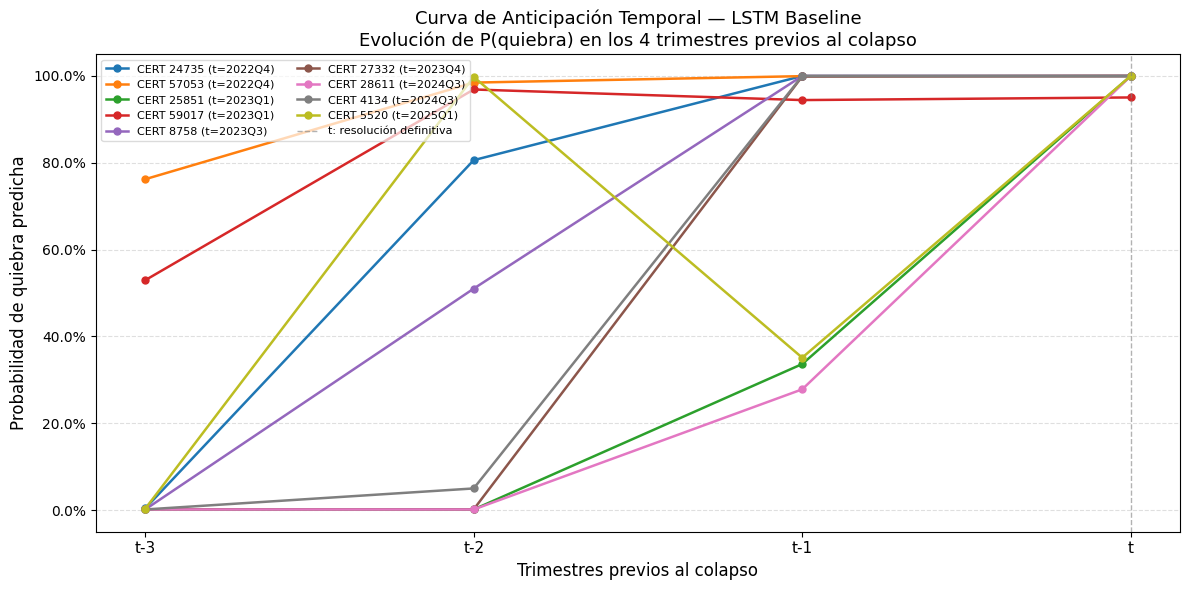

Figura guardada en: C:/dev/tfm-financial_risk/notebooks/figures/anticipation_fullcurve_hibrid.png


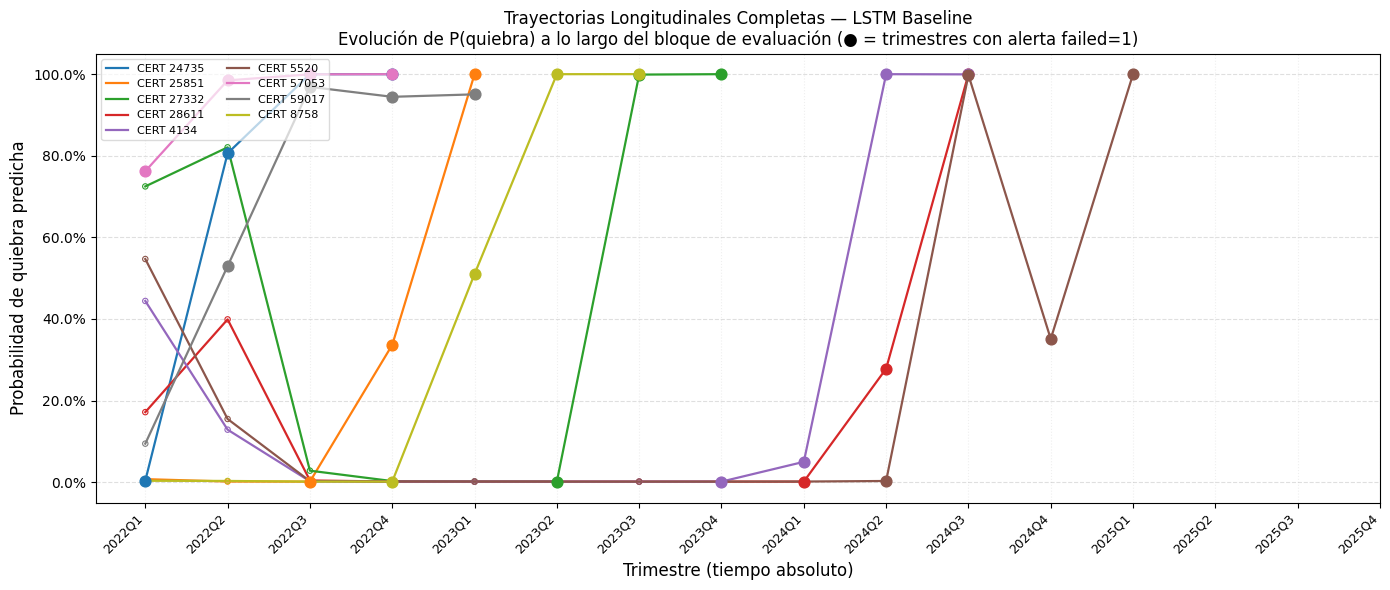

In [45]:
if "src.evaluation.metrics" in sys.modules:
    importlib.reload(sys.modules["src.evaluation.metrics"])

from src.evaluation.metrics import  build_anticipation_trajectories, plot_anticipation_curve, plot_full_trajectories


df_traj = build_anticipation_trajectories(df_preds, window=4)

plot_anticipation_curve(
    df_traj,
    window=4,
    model_label="LSTM Baseline",
    save_path="C:/dev/tfm-financial_risk/notebooks/figures/anticipation_curve_hibrid.png",
) 


plot_full_trajectories(
    df_preds,
    model_label="LSTM Baseline",
    save_path="C:/dev/tfm-financial_risk/notebooks/figures/anticipation_fullcurve_hibrid.png",
)

Las trayectorias del modelo estrella son mas caoticas que las del Baseline y eso tiene una explicacion directa.
El Baseline muestra un patron de anticipacion monotono o casi monotono en la mayoria de entidades: la probabilidad crece de forma progresiva conforme se acerca el trimestre de quiebra (t3 bajo, t2 medio, t1 alto, t0 muy alto). Eso indica que el LSTM sobre e_tab aprende una trayectoria de deterioro suave y acumulativa.
El modelo estrella en cambio muestra dos patrones distintos. Algunas entidades tienen trayectorias coherentes como 24735, 57053 o 27332 donde la probabilidad sube progresivamente. Pero otras tienen saltos abruptos como 25851 que pasa de 0.999 en t0 a 0.336 en t1 y luego a 0.001, o 28611 que tiene 0.999 en t0 y 0.278 en t1 con caida brusca, o 5520 que oscila entre 0.998 en t2, 0.351 en t1 y 0.999 en t0.
La razon de este comportamiento es la naturaleza del estado oculto del T-GCN. e_rel en cada trimestre depende no solo de la historia del banco individual sino tambien de la estructura del grafo en ese trimestre y del estado de sus vecinos. Un cambio en la composicion del holding, la entrada o salida de bancos vecinos, o un cambio en la conectividad del grafo puede producir saltos abruptos en h_i^t que el LSTM no puede suavizar si no hay una tendencia clara en la secuencia de e_rel. El Baseline no tiene esta sensibilidad porque e_tab es una representacion puramente individual sin dependencia de vecinos.
Esto es en si mismo un resultado interpretable para la memoria: el modelo estrella captura discontinuidades estructurales en el grafo que el Baseline ignora, pero esas discontinuidades introducen ruido en la trayectoria temporal que perjudica la anticipacion sistematica. Es un trade-off entre sensibilidad estructural y estabilidad temporal.

# Interpretabilidad SHAP

In [50]:
if "src.evaluation.interpretability" in sys.modules:
    importlib.reload(sys.modules["src.evaluation.interpretability"])

from src.evaluation.interpretability import (
    build_shap_inputs,
    compute_gradient_shap,
    aggregate_shap_by_timestep,
    build_shap_summary,
    plot_shap_timestep_importance,
)

shap_inputs = build_shap_inputs(
    sequences_train=sequences_rel_train,      # secuencias de desarrollo con e_rel
    sequences_eval=sequences_rel_eval,    # secuencias de evaluacion con e_rel
    n_background=100,
    n_global_sample=2000,
    seed=42,
    device=device,
)

print(f"Background:    {shap_inputs['background'].shape}")   # (100, 4, 32)
print(f"Global inputs: {shap_inputs['global_inputs'].shape}") # (2000, 4, 32)
print(f"Local inputs:  {shap_inputs['local_inputs'].shape}")  # (33, 4, 32)

Background:    torch.Size([100, 4, 32])
Global inputs: torch.Size([2000, 4, 32])
Local inputs:  torch.Size([33, 4, 32])


In [51]:
# 2. SHAP values — análisis GLOBAL (2.000 secuencias)

shap_values_global = compute_gradient_shap(
    models=models,
    background=shap_inputs["background"],
    inputs=shap_inputs["global_inputs"],
    n_samples=50,
    batch_size=256,
    seed=42,
)

shap_by_timestep_global = aggregate_shap_by_timestep(shap_values_global, absolute=True)

df_shap_global = build_shap_summary(
    shap_by_timestep=shap_by_timestep_global,
    labels=shap_inputs["global_labels"],
    period_ends=shap_inputs["global_periods"],
    certs=shap_inputs["global_certs"],
    absolute=True,
)


In [52]:
# 3. SHAP values — análisis LOCAL (33 secuencias positivas)

shap_values_local = compute_gradient_shap(
    models=models,
    background=shap_inputs["background"],
    inputs=shap_inputs["local_inputs"],
    n_samples=50,
    batch_size=256,
    seed=42,
)

shap_by_timestep_local = aggregate_shap_by_timestep(shap_values_local, absolute=False)

df_shap_local = build_shap_summary(
    shap_by_timestep=shap_by_timestep_local,
    labels=shap_inputs["local_labels"],
    period_ends=shap_inputs["local_periods"],
    certs=shap_inputs["local_certs"],
    absolute=False,
)

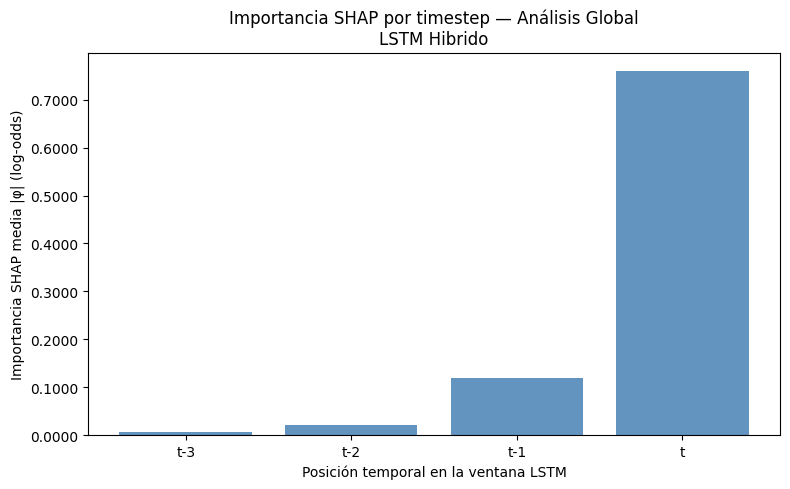

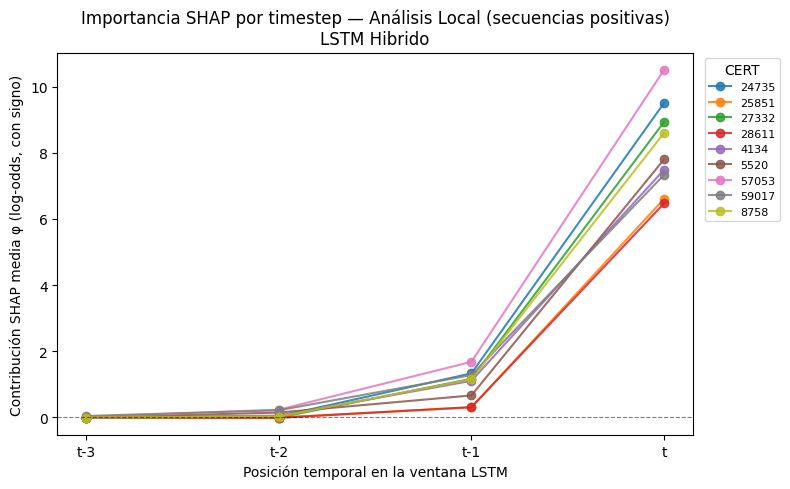

In [53]:

plot_shap_timestep_importance(df_shap_global, subset="global", model_label="LSTM Hibrido")
plot_shap_timestep_importance(df_shap_local, subset="local", model_label="LSTM Hibrido")

El Baseline muestra una distribucion de importancia temporal mas equilibrada. t tiene el mayor peso (1.02) pero los trimestres anteriores contribuyen de forma apreciable: t-3 con 0.18, t-2 con 0.19, t-1 con 0.28. La historia temporal de los cuatro trimestres es relevante para la decision, con un gradiente suave de importancia creciente hacia el presente.
El modelo estrella en cambio esta completamente dominado por t, el trimestre actual, con importancia 0.75 frente a valores casi nulos en t-3 (0.008), t-2 (0.025) y t-1 (0.125). El LSTM sobre e_rel ignora practicamente toda la historia temporal y basa su decision casi exclusivamente en el estado oculto del trimestre inmediatamente anterior a la quiebra.
Esto tiene una explicacion directa. e_rel ya contiene memoria temporal acumulada dentro del propio estado oculto del T-GCN, que propaga informacion de trimestres anteriores a traves de la celda GRU. El LSTM recibe en cada paso t una representacion que ya integra la historia del banco hasta ese momento, por lo que no necesita mirar atras en la ventana de 4 trimestres para recuperar informacion historica: ya esta implicitamente codificada en e_rel_t. El resultado es que el LSTM aprende a confiar casi exclusivamente en el ultimo estado relacional disponible.
Esto es un resultado interpretable y coherente con la arquitectura, pero tambien explica parte de las trayectorias caoticas observadas antes: si el modelo depende casi exclusivamente de t, cualquier discontinuidad en e_rel en el trimestre inmediatamente anterior a la quiebra produce predicciones inestables en los trimestres previos.

Los dos modelos comparten el patron general de contribucion creciente hacia t, con valores casi nulos en t-3 y una aceleracion marcada en t-1 y t. Eso es esperado y coherente con lo ya visto en el analisis global.
Las diferencias relevantes son tres.
La escala de contribucion en t es mayor en el modelo estrella que en el Baseline para varios CERTs. CERT 57053 alcanza 10.5 en el modelo estrella frente a valores en torno a 8-9 en el Baseline. Esto indica que cuando el modelo estrella detecta una quiebra, lo hace con una señal mas concentrada y extrema en el ultimo trimestre, lo que es coherente con la dependencia casi exclusiva de t documentada en el analisis global.
La dispersion entre CERTs en t-1 es mayor en el Baseline. En el Baseline ya hay separacion visible entre entidades en t-1, con CERT 59017 destacando claramente sobre los demas con contribucion 2.7. En el modelo estrella las curvas en t-1 estan mas agrupadas alrededor de 1.0-1.8, con menos diferenciacion entre casos. El modelo estrella no distingue bien entre entidades hasta el ultimo trimestre.
CERT 28611 es el caso mas ilustrativo de la diferencia entre modelos. En el Baseline tiene contribucion positiva en t-2 y t-1 antes de llegar a t, mostrando una señal de deterioro progresivo. En el modelo estrella su curva es plana hasta t-1 y sube abruptamente en t, lo que explica por que el Baseline lo detecta en rank 2 en 2024Q2 mientras el modelo estrella lo coloca en rank 18.
La conclusion interpretativa es consistente con todo lo anterior: el modelo estrella concentra su capacidad discriminativa en el estado relacional del trimestre inmediatamente anterior a la quiebra, sacrificando la capacidad de anticipacion gradual que el Baseline construye a lo largo de los cuatro trimestres de la ventana.